# 14 · The real Brain-Score: CLIP predicts IT neural responses

CLIP ViT-B/32, from images alone, predicting held-out MajajHong2015 IT neural
responses (168 recording sites, 3200 images). The scoring runs on EC2 — real
neural data plus cross-validated PLS. This notebook plots the saved predictions;
the scoring code is at the end.

## Predicted vs measured, one IT site

Each point is one image: measured held-out response vs CLIP's prediction.

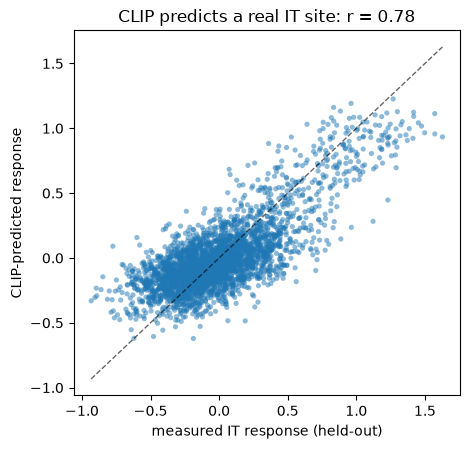

In [1]:
import numpy as np
import matplotlib.pyplot as plt

d = np.load('assets/clip_majajhong_it.npz')
y, p = d['measured'], d['predicted']
r = float(d['best_r']); median_r = float(d['median_r'])

fig, ax = plt.subplots(figsize=(4.8, 4.6))
ax.scatter(y, p, s=14, alpha=0.5, edgecolor='none')
lo, hi = float(np.min([y, p])), float(np.max([y, p]))
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.6)
ax.set_xlabel('measured IT response (held-out)')
ax.set_ylabel('CLIP-predicted response')
ax.set_title(f'CLIP predicts a real IT site: r = {r:.2f}')
fig.tight_layout(); plt.show()

## Across all 168 IT sites

Per-site predictivity. The benchmark's own metric reports the same median.

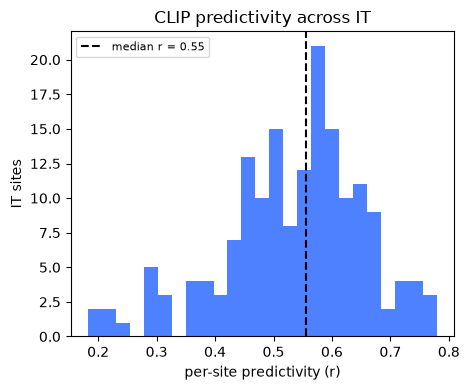

median r = 0.555 across 168 IT sites; best site r = 0.779


In [2]:
rs = d['per_neuroid_r']
fig, ax = plt.subplots(figsize=(4.8, 4.0))
ax.hist(rs[~np.isnan(rs)], bins=25, color='#2f6bff', alpha=0.85)
ax.axvline(median_r, c='k', ls='--', label=f'median r = {median_r:.2f}')
ax.set_xlabel('per-site predictivity (r)'); ax.set_ylabel('IT sites')
ax.set_title('CLIP predictivity across IT'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()
print(f'median r = {median_r:.3f} across {len(rs)} IT sites; best site r = {r:.3f}')

## How it was produced (EC2)

Real neural data plus PLS is heavier than a laptop path, so this ran on EC2:

```python
import brainscore
model = brainscore.load_model('clip-vit-b-32')
bench = brainscore.load_benchmark('MajajHong2015public.IT-pls-unified')

model.start_recording('IT')
features = model.process(bench._assembly.stimulus_set)   # (3200, 38400)

# the benchmark's own metric gives the score directly:
score = bench._similarity_metric(features, bench._assembly)   # ~0.55

# for the scatter, reproduce its CV and keep held-out predictions:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import StratifiedShuffleSplit
# StratifiedShuffleSplit(10, train_size=0.9) by object_name, PLSRegression(25),
# per-split Pearson averaged per site — capture pls.predict(X_test) per fold.
```

The full score through the public surface is `brainscore.score('clip-vit-b-32',
'MajajHong2015public.IT-pls-unified')`.

For a laptop-safe look at model representations without neural data, see
notebook 13.